## Détection supervisée des profils atypiques par Random Forest ##

L'objectif de cette partie est de construire un modèle de classification supervisée capable d'identifier les profils atypiques à partir des caractéristiques comportementales et sociales extraites des utilisateurs Twitter.

Le modèle choisi est le Random Forest, reconnu pour sa robustesse, sa capacité à gérer des données hétérogènes et son aptitude à identifier les variables les plus influentes dans le processus de décision.

**1. Construction de la variable cible**

Il faut définir une règle métier permettant d'identifier les profils atypiques à partir de plusieurs indicateurs comportementaux.

Les critères retenus sont :

- un ratio followers/friends très faible ;
- une activité anormalement élevée ;
- une utilisation excessive des hashtags ;
- une faible visibilité du compte.

Ces comportements sont fréquemment observés dans les profils automatisés, spammeurs ou atypiques.

In [15]:
# Chargement des données

import pandas as pd 

twitter= pd.read_csv("../dataset/user_twitter_data.csv")

twitter

,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,urls_count,mentions_count,tweet_length,is_retweet,is_quote,lang,n_tweets,followers_friends_ratio,activity_ratio,visibility_score
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,1,0,0,...,0.5,0.666667,113.333333,0.5,0.5,en,6,35.316681,0.758082,133252.333333
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,0,0,0,...,0.0,1.000000,139.000000,1.0,1.0,en,1,3.234375,19.548232,821.000000
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,0,0,0,...,1.0,0.000000,31.000000,0.0,1.0,en,1,9.425620,6.514135,6442.000000
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,1,0,0,...,0.0,0.000000,88.000000,0.0,0.0,en,1,19.537273,0.645775,40321.000000
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,0,0,0,...,0.0,1.000000,140.000000,0.0,0.0,en,1,4.704813,2.662955,7079.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843434,1008392352644386816,vernett97925119,0.000000,0.000000,3.000000,0.0,0.0,0,1,0,...,0.0,1.000000,75.000000,1.0,0.0,en,1,0.000000,3.000000,0.000000
1843435,1008392445837692933,jacquly32294003,0.000000,0.000000,5.000000,0.0,0.0,0,1,0,...,0.0,1.000000,75.000000,1.0,0.0,en,1,0.000000,5.000000,0.000000
1843436,1008392594878066688,merrileenentwi5,0.000000,0.000000,14.000000,0.0,0.0,0,1,0,...,0.0,1.000000,140.000000,1.0,0.0,en,1,0.000000,14.000000,0.000000
1843437,1008392729930366976,annabel17990985,0.000000,0.000000,1.000000,0.0,0.0,0,1,0,...,0.0,1.000000,75.000000,1.0,0.0,en,1,0.000000,1.000000,0.000000


In [16]:
# Seuil de visibilité 
seuil_visibility = twitter["visibility_score"].quantile(0.25)

print("Seuil visibilité :", seuil_visibility)

Seuil visibilité : 117.0


Ici , on définit un seuil de visibilité à partir du premier quartile de la distribution; ainsi  les 25 % les moins visibles sont considérés comme potentiellement suspects

**2.Construction du score d'atypicité**

On a choisit un ensemble de 4 critéres permettant de capturer différentes dimensions du comportement d'un utilisateur :sa popularité relative ; son niveau d'activité ; sa stratégie de diffusion de contenu ;son impact réel sur la plateforme. 

Chaque critère validé ajoute un point au score.

In [17]:
# critère 1 : Ratio followers/Friends

critere_ratio = (
    twitter["followers_friends_ratio"] < 0.05
).astype(int)

# critère 2 : activité très élevée

critere_activity = (
    twitter["activity_ratio"] > 20
).astype(int)

# critère 3: utilisation excessive de hashtags

critere_hashtags = (
    twitter["hashtags_count"] > 10
).astype(int)

# critère 4 : visibilité faible

critere_visibility = (
    twitter["visibility_score"] < seuil_visibility
).astype(int)

# calcul du score global

score = (
    critere_ratio
    + critere_activity
    + critere_hashtags
    + critere_visibility
)

twitter["score_atypique"] = score

score.value_counts().sort_index() 

0    738714
1    898701
2    191346
3     14658
4        20
Name: count, dtype: int64

**3.Création de la variable cible et vérification de la répartition des classes**

La variable cible est définie comme suit :

0 pour	Profil normal et 1 pour	Profil atypique.

Un utilisateur est considéré comme atypique lorsqu'il satisfait au moins deux critères parmi les quatre retenus.

In [18]:
# Variable cible

twitter["atypique"] = (
    score >= 2
).astype(int)

twitter["atypique"].value_counts()

twitter["atypique"].value_counts(normalize=True) * 100

atypique
0    88.823932
1    11.176068
Name: proportion, dtype: float64

La majorité des utilisateurs sont classés comme normaux tandis qu'environ 11,17 % présentent des comportements atypiques.

In [19]:
# Affichage de quelques profils atypiques 

profils_atypiques = twitter[twitter["atypique"] == 1]

print(profils_atypiques.shape)
profils_atypiques.head()

(206024, 27)


,user_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,verified,default_profile,default_profile_image,...,tweet_length,is_retweet,is_quote,lang,n_tweets,followers_friends_ratio,activity_ratio,visibility_score,score_atypique,atypique
343,765621,zenera,45.0,54.5,8711.5,437.5,6.0,0,0,0,...,105.5,1.0,0.0,en,2,0.810811,189.380435,105.0,2,1
345,766993,edutitta,37.0,25.0,8682.0,67.0,2.0,0,0,0,...,64.0,0.0,0.0,en,1,1.423077,228.473684,57.0,2,1
446,806339,snowesq,65.0,188.0,1455.0,1036.0,2.0,0,0,0,...,135.0,0.0,0.0,en,1,0.343915,22.045455,85.0,2,1
453,807690,GepferiaGirl,45.0,256.0,1667.0,5109.0,3.0,0,0,0,...,140.0,1.0,0.0,en,1,0.175097,36.239130,75.0,2,1
487,818720,kendickson,78.0,333.0,3004.0,619.0,3.0,0,0,0,...,100.0,1.0,0.0,fr,1,0.233533,38.025316,108.0,2,1


**4.Sélection des variables d'entraînement**

On fournir au modèle les informations les plus pertinentes pour prédire la classe d'un utilisateur.Pour éviter le data leakage, on retire les variables utilisées pour construire le label.

In [20]:
features_rf = [

    "followers_count",
    "friends_count",
    "statuses_count",
    "favourites_count",
    "listed_count",

    "retweet_count",
    "favorite_count",
    "reply_count",
    "quote_count",

    "urls_count",
    "mentions_count",

    "tweet_length",

    "is_retweet",
    "is_quote",

    "n_tweets"

]

# Contruction de X et y

X = twitter[features_rf]

y = twitter["atypique"]

# Séparation train/test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1474751, 15)
(368688, 15)


**5.Création du modèle Random Forest**

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=15,

    min_samples_split=10,

    min_samples_leaf=5,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1
)

# Entraînement du modèle 

model= rf.fit(X_train, y_train)

model


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

**6.Evaluation du modèle**

In [22]:
# Prédictions

y_pred = rf.predict(X_test)

# Matrice de confusion

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[316922  10561]
 [   177  41028]]


In [23]:
# Rapport de classification

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
) 

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    327483
           1       0.80      1.00      0.88     41205

    accuracy                           0.97    368688
   macro avg       0.90      0.98      0.93    368688
weighted avg       0.98      0.97      0.97    368688



On a un recall= 1.00 Pour la classe 1, ce qui signifie que l'ensemble des profils atypiques présents dans les données de test ont été correctement identifiés par le modèle.

La précision de 80 % indique que la majorité des profils détectés comme atypiques correspondent effectivement à des comportements atypiques. Toutefois, une proportion limitée de profils normaux est également signalée par erreur.

Le F1-score=0.88 montre aussi que le modèle est capable de détecter les profils atypiques sans générer trop d'erreurs.

Pour la classe normal le modèle détecte 97% des profils normaux et seul quelques profils sont confondus avec des atypiques. Un précision= 1.00

Ainsi le modèle obtient d'excellentes performances pour reproduire la définition métier retenue des profils atypiques.

**7.Visualisation de la matrice de confusion**

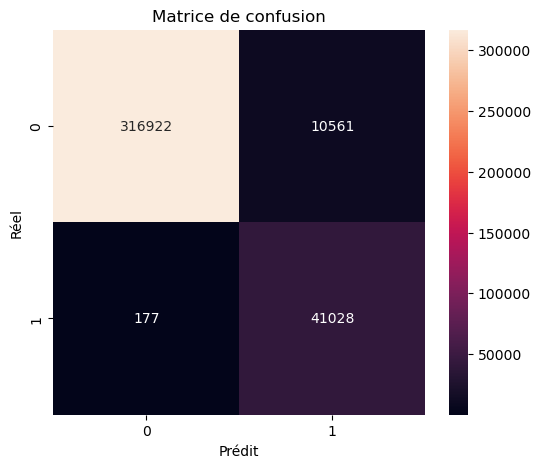

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel") 

plt.show()

On peut voir que seuls 117 profils atypiques (faux négatifs) n'ont pas été identifiés. En revanche, 10 561 profils normaux sont signalés à tort comme atypiques(faux positif).

**8.Importance des variables**

In [25]:
importance = pd.DataFrame({

    "feature": X.columns,

    "importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

             feature  importance
0    followers_count    0.643366
2     statuses_count    0.117471
4       listed_count    0.115856
1      friends_count    0.087951
3   favourites_count    0.022031
11      tweet_length    0.004360
12        is_retweet    0.003280
10    mentions_count    0.002366
9         urls_count    0.001181
14          n_tweets    0.001135
13          is_quote    0.001004
6     favorite_count    0.000000
5      retweet_count    0.000000
7        reply_count    0.000000
8        quote_count    0.000000


<Figure size 1000x600 with 0 Axes>

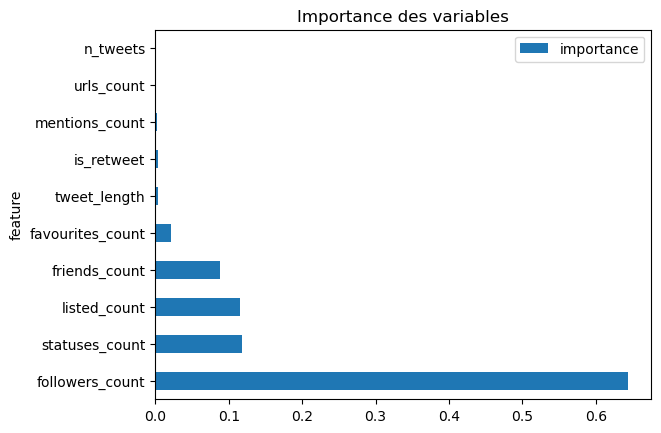

In [26]:
# Visualisation des variables importantes

plt.figure(figsize=(10,6))

importance.head(10).plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.title(
    "Importance des variables"
)

plt.show() 

**Validation croisée**

In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="f1"
)

print(scores)

print(scores.mean())

[0.96486506 0.95246622 0.93499687 0.89529812 0.64757449]
0.8790401509979059


Cette validation croisée réalisée à l'aide du F1-score confirme les performances du modèle. Le score moyen obtenu est de 87,9 %, ce qui traduit un bon compromis entre précision et rappel. Malgré une légère variabilité observée entre les différents plis, les résultats restent bons.